# Optymalizacja AUV — Prototyp v0.2

Drugi notebook prototypu. Ustalenia z EDA, które są podstawą tego kroku:

- **$t_0$ = 2017-06-30** (najbliższy koniec miesiąca do 2017-06-01, środek najnowszej spokojnej ery).
- **Funkcja celu: wersja A — na poziomach.** Decyzja podjęta po tym, jak EDA pokazała, że log-stopy zwrotu surowców są już prawie nieskorelowane z M2 — minimalizacja tej korelacji w stopach zwrotu byłaby bezprzedmiotowa.
- **Procedura: Frisch-Waugh-Lovell + QP.** Najpierw regresja log-poziomów każdego surowca na log-poziomy M2 (USA, EU, UK, JP) — to daje resztę reprezentującą "realną" część ceny. Następnie QP szukające wag minimalizujących wariancję ważonej sumy reszt.
- **Walidacja krzyżowa:** ostatnia główna składowa PCA na tych samych resztach — powinna dawać podobny kierunek.

Cel notebooka: zobaczyć, czy ta procedura produkuje sensowne wagi i sensowne AUV(t).

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)

PROTOTYP_ROOT = Path.cwd().parent
if str(PROTOTYP_ROOT) not in sys.path:
    sys.path.insert(0, str(PROTOTYP_ROOT))

from src.optimize import (
    construct_auv,
    fwl_residuals,
    pca_weights,
    run_auv_pipeline,
    solve_qp,
)

DATA_DIR = PROTOTYP_ROOT / 'data' / 'processed'
FIG_DIR = PROTOTYP_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR = PROTOTYP_ROOT / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

monthly = pd.read_parquet(DATA_DIR / 'monthly.parquet')
print(f'Loaded monthly: {monthly.shape}')

Loaded monthly: (360, 31)


## 1. Uruchomienie pełnego pipeline'u

Wybór składników:

- **Surowce do koszyka** (8): brent, wti, natgas_us, wheat, corn, copper, aluminum, iron_ore.
- **Agregaty monetarne do FWL** (4): M2_USA, M3_EU, M3_UK, M2_JP. 
  M2_CN i M2_BR pomijamy w v0.2 prototypu — kończą się przed 2020 (forward-fill zniekształciłby regresję). M3_PL nadal nie mamy.

Funkcja `run_auv_pipeline` robi: FWL → QP → PCA → konstrukcja AUV(t).

In [2]:
COMMODITIES = ['brent', 'wti', 'natgas_us', 'wheat', 'corn', 'copper', 'aluminum', 'iron_ore']
MONEY = ['M2_USA', 'M3_EU', 'M3_UK', 'M2_JP']
T0 = '2017-06-30'

result = run_auv_pipeline(
    monthly=monthly,
    commodities=COMMODITIES,
    money_aggregates=MONEY,
    t0=T0,
)
result.save(OUTPUTS_DIR)

print(f'\nOkres FWL: {result.metadata["period_start"]} → {result.metadata["period_end"]}')
print(f'Obserwacji w regresji: {result.metadata["n_observations"]}')
print(f'\nStd reszt ważona — QP:  {result.auv_residual_std:.4f}')
print(f'Std reszt ważona — PCA: {result.auv_residual_std_pca:.4f}')


Okres FWL: 1997-01-31 → 2025-12-31
Obserwacji w regresji: 348

Std reszt ważona — QP:  0.1160
Std reszt ważona — PCA: 0.2737


## 2. Współczynniki β z FWL — "jak surowiec reaguje na M2"

Każdy wiersz to surowiec, każda kolumna to agregat M2/M3. Wartość β oznacza: ile log p_i rośnie na jednostkę log M2 (po kontroli pozostałych M2). β > 1 = surowiec rośnie *szybciej* niż dany agregat (silniej zinflowany niż dolar). β < 0 = surowiec zachowuje się przeciwnie do M2 (rzadkie).

Spodziewamy się β bliskich 1 dla M2 USA (bo ceny są w USD), zmieszanych dla pozostałych.

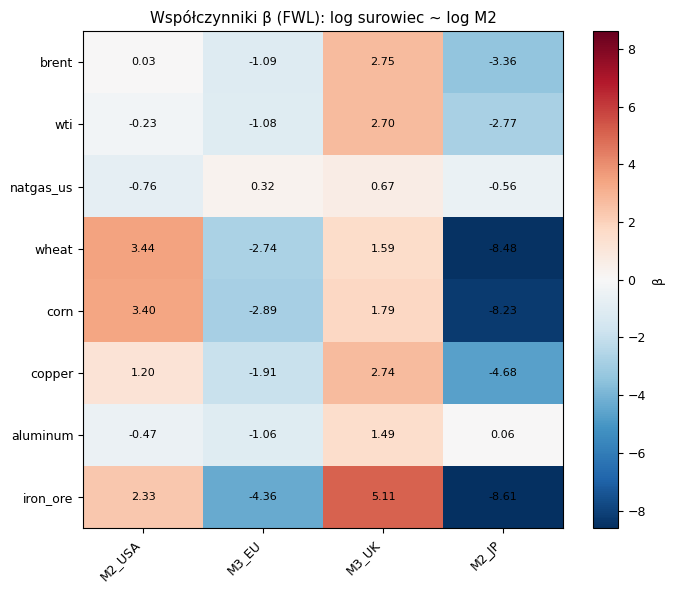

Suma β po wszystkich M2 dla każdego surowca:
  brent          Σβ = -1.668
  wti            Σβ = -1.373
  natgas_us      Σβ = -0.331
  wheat          Σβ = -6.191
  corn           Σβ = -5.933
  copper         Σβ = -2.642
  aluminum       Σβ = +0.013
  iron_ore       Σβ = -5.524


In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
betas_num = result.betas.astype(float)
vmax = max(abs(betas_num.values.min()), abs(betas_num.values.max()))
im = ax.imshow(betas_num.values, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(betas_num.columns)))
ax.set_xticklabels(betas_num.columns, rotation=45, ha='right')
ax.set_yticks(range(len(betas_num.index)))
ax.set_yticklabels(betas_num.index)
ax.set_title('Współczynniki β (FWL): log surowiec ~ log M2')

for i in range(betas_num.shape[0]):
    for j in range(betas_num.shape[1]):
        val = betas_num.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='β')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_betas_fwl.png', dpi=150, bbox_inches='tight')
plt.show()

print('Suma β po wszystkich M2 dla każdego surowca:')
for c in betas_num.index:
    total = betas_num.loc[c].sum()
    print(f'  {c:14s} Σβ = {total:+.3f}')

## 3. Wagi koszyka — QP vs PCA

Dwie metody dla tego samego zadania (minimum wariancji reszt). Jeśli wagi są zbliżone, mamy walidację metodologiczną. Jeśli się rozjeżdżają — sygnał, że trzeba zinterpretować.

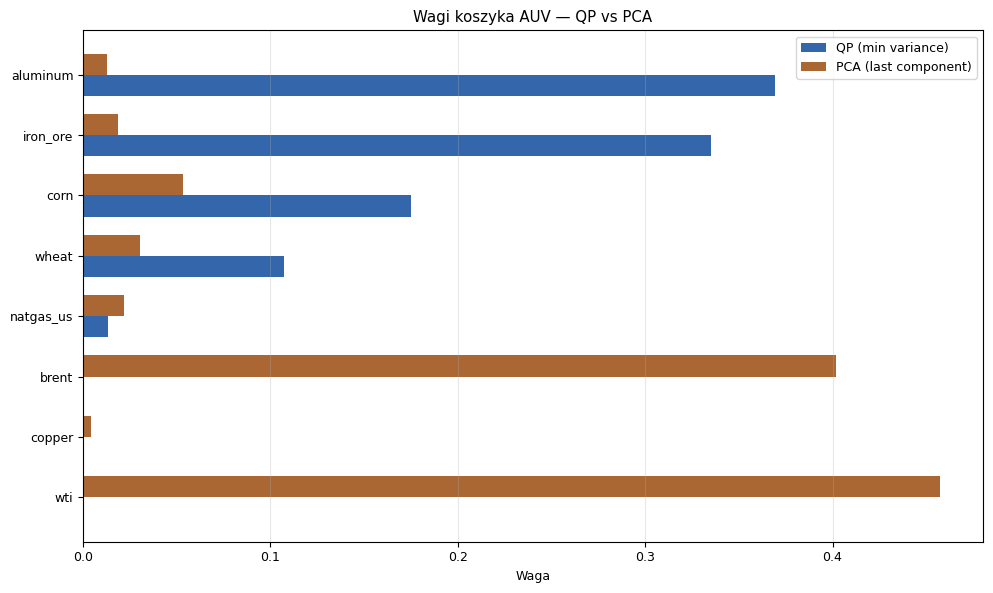


Wagi posortowane (QP):
  aluminum       36.911%
  iron_ore       33.536%
  corn           17.484%
  wheat          10.737%
  natgas_us      1.332%
  brent          0.000%
  wti            0.000%
  copper         0.000%


In [4]:
weights_compare = pd.DataFrame({
    'QP': result.weights_qp,
    'PCA': result.weights_pca,
}).sort_values('QP', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(weights_compare))
width = 0.35
ax.barh(x - width/2, weights_compare['QP'], width, label='QP (min variance)', color='#3366aa')
ax.barh(x + width/2, weights_compare['PCA'], width, label='PCA (last component)', color='#aa6633')
ax.set_yticks(x)
ax.set_yticklabels(weights_compare.index)
ax.set_xlabel('Waga')
ax.set_title('Wagi koszyka AUV — QP vs PCA')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_weights_qp_vs_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nWagi posortowane (QP):')
for col, w in result.weights_qp.sort_values(ascending=False).items():
    print(f'  {col:14s} {w:.3%}')

## 4. AUV(t) — wynik podstawowy

Wskaźnik wyznaczony jako: $\text{AUV}(t) = \frac{\sum w_i p_i(t)}{\sum w_i p_i(t_0)} \cdot 100$, gdzie wagi pochodzą z QP, a $t_0$ = 2017-06-30.

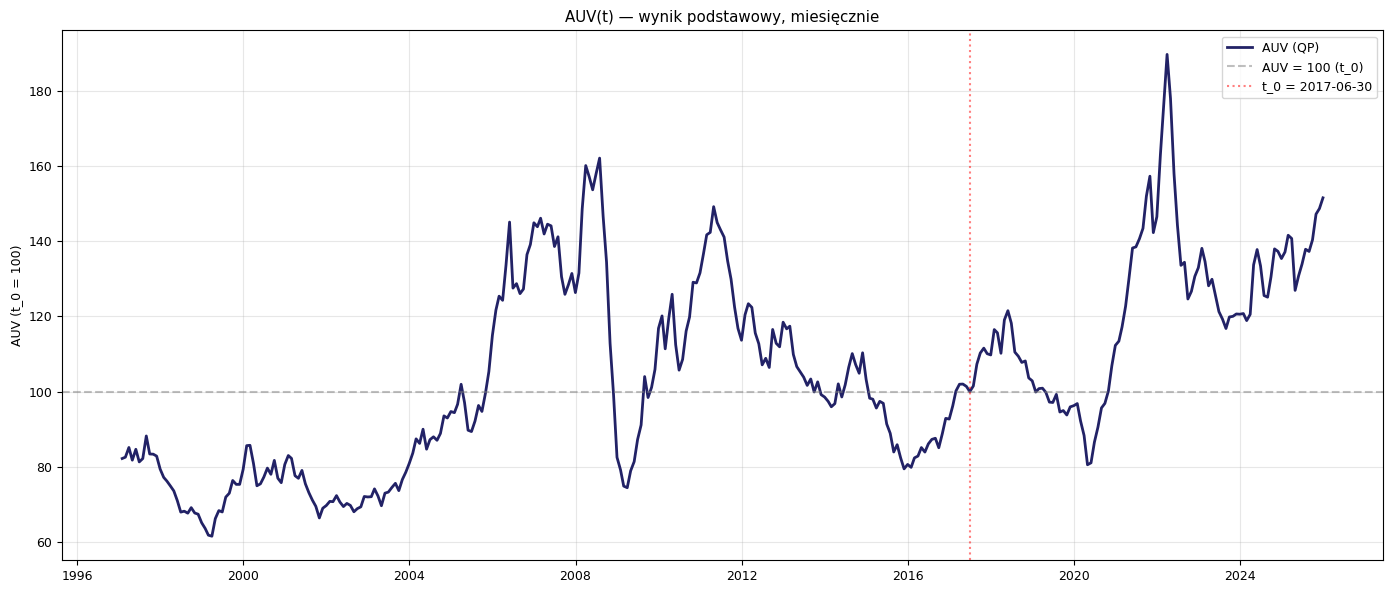


AUV w 1996: nan
AUV w t_0 (2017-06): 100.0
AUV obecne (2025-12): 151.5

Zmiana 1996 → 2025: +nan%
Zmiana t_0 → 2025:   +51.5%


In [5]:
auv = result.auv_series

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(auv.index, auv.values, color='#222266', linewidth=2, label='AUV (QP)')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='AUV = 100 (t_0)')
ax.axvline(pd.Timestamp(T0), color='red', linestyle=':', alpha=0.5, label=f't_0 = {T0}')
ax.set_title('AUV(t) — wynik podstawowy, miesięcznie')
ax.set_ylabel('AUV (t_0 = 100)')
ax.grid(alpha=0.3)
ax.legend()

# Anotacja kluczowych dat
for date, label in [
    ('2008-09-01', 'Lehman'),
    ('2020-03-01', 'COVID'),
    ('2022-02-01', 'Ukraine'),
]:
    d = pd.Timestamp(date)
    if d in auv.index:
        ax.annotate(label, xy=(d, auv.loc[d]), xytext=(0, 25),
                    textcoords='offset points', fontsize=9,
                    arrowprops=dict(arrowstyle='->', alpha=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / '08_auv_basic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAUV w 1996: {auv.iloc[0]:.1f}')
print(f'AUV w t_0 (2017-06): {auv.loc[pd.Timestamp(T0)]:.1f}')
print(f'AUV obecne (2025-12): {auv.iloc[-1]:.1f}')
print(f'\nZmiana 1996 → 2025: {(auv.iloc[-1] / auv.iloc[0] - 1) * 100:+.1f}%')
print(f'Zmiana t_0 → 2025:   {(auv.iloc[-1] / auv.loc[pd.Timestamp(T0)] - 1) * 100:+.1f}%')

## 5. AUV vs M2_USA — walidacja heliocentryczna

Najważniejszy wykres walidacyjny. Jeżeli AUV ma być "niezależny od ekspansji monetarnej", to porównanie z M2_USA pokaże, czy procedura zadziałała.

Oba szeregi w log-skali, znormalizowane do $t_0 = 100$.

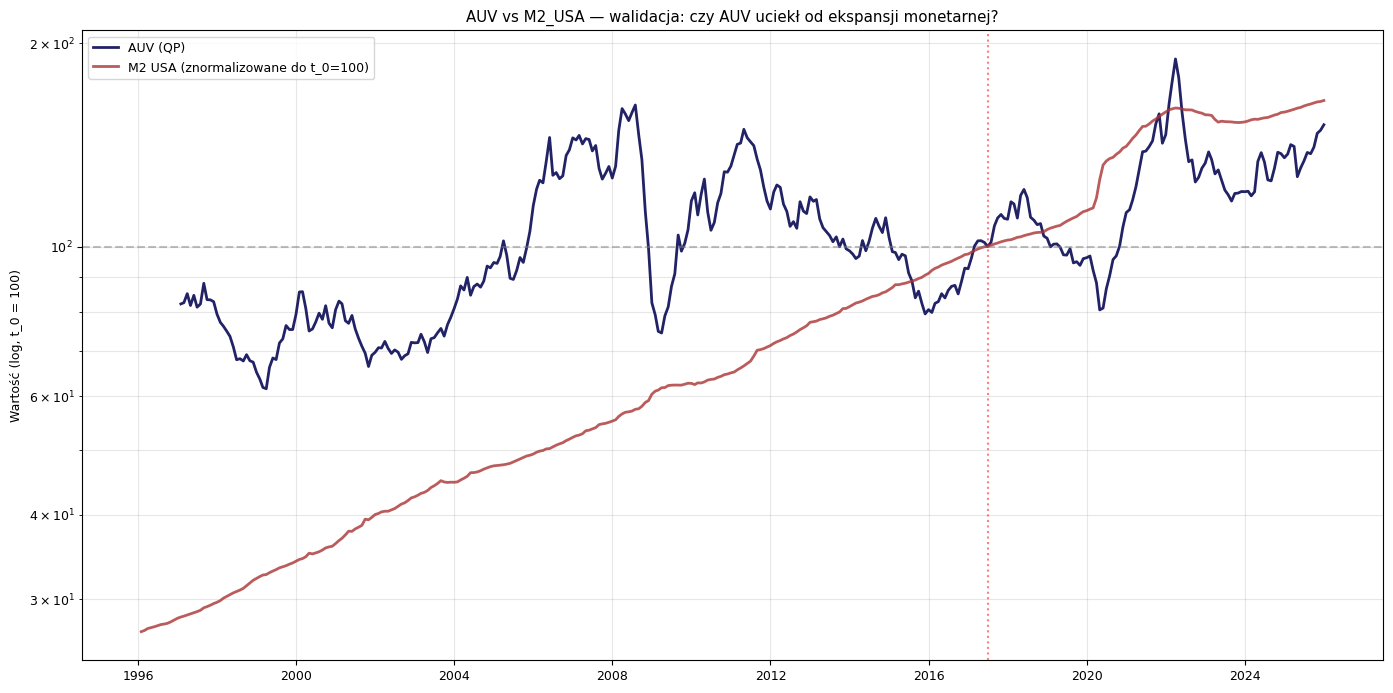

In [6]:
t0_ts = pd.Timestamp(T0)
m2_usa = monthly['M2_USA'].dropna()
m2_usa_normalized = m2_usa / m2_usa.loc[m2_usa.index[m2_usa.index.get_indexer([t0_ts], method='nearest')[0]]] * 100

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(auv.index, auv.values, color='#222266', linewidth=2, label='AUV (QP)')
ax.plot(m2_usa_normalized.index, m2_usa_normalized.values, color='#aa3333', linewidth=2,
        label='M2 USA (znormalizowane do t_0=100)', alpha=0.8)
if 'gold' in monthly.columns and monthly['gold'].notna().sum() > 100:
    gold = monthly['gold'].dropna()
    gold_norm = gold / gold.loc[gold.index[gold.index.get_indexer([t0_ts], method='nearest')[0]]] * 100
    ax.plot(gold_norm.index, gold_norm.values, color='#cc9933', linewidth=1.5, alpha=0.7, label='Gold (kontrola)')

ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax.axvline(t0_ts, color='red', linestyle=':', alpha=0.5)
ax.set_yscale('log')
ax.set_title('AUV vs M2_USA — walidacja: czy AUV uciekł od ekspansji monetarnej?')
ax.set_ylabel('Wartość (log, t_0 = 100)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_auv_vs_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Waluty mierzone w AUV — "ile USD/EUR/PLN za 1 AUV"

Tu widać, do czego AUV ma służyć. Jeśli wartość waluty mierzona w AUV maleje, oznacza to *realną* deprecjację — niezależnie od tego, co pokazuje oficjalny CPI.

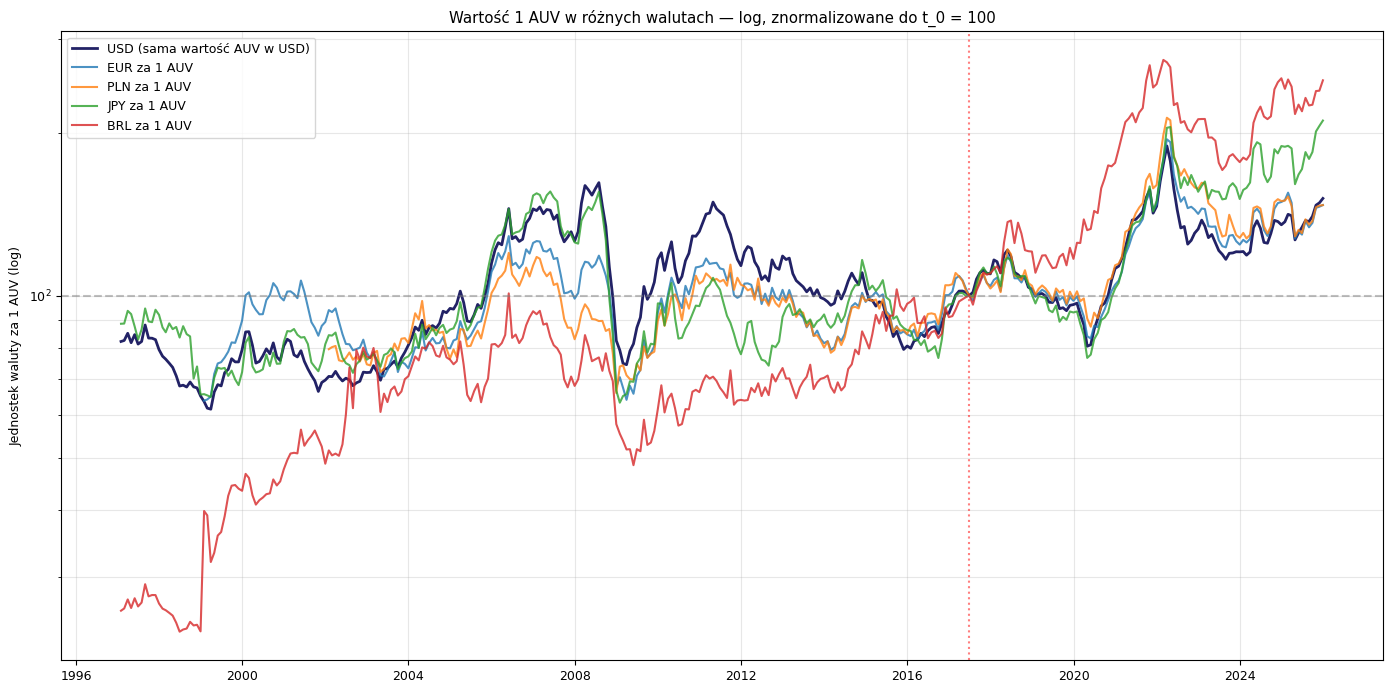


Realna deprecjacja walut względem AUV (t_0 = 2017-06 do 2025):
  EUR: +47.3%
  PLN: +47.2%
  JPY: +111.4%
  BRL: +151.1%
  USD: +51.5%


In [7]:
# AUV jest w USD (bo ceny surowców są w USD). Żeby uzyskać "USD za 1 AUV",
# odwracamy: USD/AUV(t) = AUV(t_0_value) / AUV(t) skaluje do AUV w jednostkach pieniężnych t_0.
# Prościej: po prostu auv to jest 'koszyk wycenia USD w czasie' — jego wzrost
# = realna deprecjacja USD.
#
# Dla innych walut: AUV_in_X(t) = AUV(t) * X_per_USD(t)
# Wzrost AUV_in_X = realna deprecjacja waluty X.

currencies_to_show = ['EUR', 'PLN', 'JPY', 'BRL', 'TRY']  # TRY pewnie brak, ale spróbuj
currencies_to_show = [c for c in currencies_to_show if c in monthly.columns]

fig, ax = plt.subplots(figsize=(14, 7))

# USD jako waluta bazowa: AUV(t) bezpośrednio (jak rośnie AUV w USD, tak słabnie USD).
ax.plot(auv.index, auv.values, color='#222266', linewidth=2, label='USD (sama wartość AUV w USD)')

# Pozostałe waluty: pomnóż AUV przez kurs Waluta/USD i znormalizuj do t_0
for currency in currencies_to_show:
    rate = monthly[currency].dropna()  # waluta_obca za 1 USD
    common = auv.index.intersection(rate.index)
    if len(common) < 12:
        continue
    auv_in_currency = auv.loc[common] * rate.loc[common]
    # Renormalizacja do t_0 = 100
    if t0_ts in auv_in_currency.index:
        auv_in_currency = auv_in_currency / auv_in_currency.loc[t0_ts] * 100
        ax.plot(auv_in_currency.index, auv_in_currency.values, alpha=0.8, linewidth=1.5,
                label=f'{currency} za 1 AUV')

ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax.axvline(t0_ts, color='red', linestyle=':', alpha=0.5)
ax.set_yscale('log')
ax.set_title('Wartość 1 AUV w różnych walutach — log, znormalizowane do t_0 = 100')
ax.set_ylabel('Jednostek waluty za 1 AUV (log)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_currencies_in_auv.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRealna deprecjacja walut względem AUV (t_0 = 2017-06 do 2025):')
for currency in currencies_to_show:
    rate = monthly[currency].dropna()
    common = auv.index.intersection(rate.index)
    if len(common) < 12 or t0_ts not in common:
        continue
    auv_in_currency = auv.loc[common] * rate.loc[common]
    val_t0 = auv_in_currency.loc[t0_ts]
    val_end = auv_in_currency.iloc[-1]
    deprecjacja = (val_end / val_t0 - 1) * 100
    print(f'  {currency}: {deprecjacja:+.1f}%')
print(f'  USD: {(auv.iloc[-1] / auv.loc[t0_ts] - 1) * 100:+.1f}%')

## Wnioski — do uzupełnienia po obejrzeniu wyników

1. **Czy procedura zbiegła do sensownych wag?** _____________ (komórka 3)
2. **Czy QP i PCA się zgadzają?** _____________ (komórka 5)
3. **Czy AUV(t) wygląda sensownie historycznie?** Czy reaguje na 2008, 2020, 2022 tak, jak intuicja podpowiada? _____________ (komórka 7)
4. **Czy AUV uciekł od M2_USA?** Jeśli linie się nie pokrywają, mamy *prawdziwą* niezależność. Jeśli się pokrywają, FWL+QP nie zadziałało. _____________ (komórka 9)
5. **Czy deprecjacja walut w AUV jest zgodna z intuicją?** PLN ma być wysoka, CHF niska. _____________ (komórka 11)
6. **Czy są oczywiste wady do naprawienia w kolejnej iteracji?** _____________